# Meeting ALM with BIIF member (Max), needs resulting from MINFLUX data

- provide script (interactive/jupyter notebook style) to read in raw msr MINFLUX data
- do short-trace filtering (remove traces with <3 localizations) and EFO filtering (interactive, based on peaks)
- save as csv for continued data analysis
- drift correction

### LOC and LNC

In the exported data there are two types of localization coordinates: the MINFLUX Beamline Monitoring (MBM) corrected, called LOC, and the raw localizations, named LNC which stands for Localizations not corrected. Both fields have three columns, one for each 3D cartesian coordinate: x, y, and z.

### Z-correction

Around 0.7x.

### Valid (VLD)

The valid field contains logical values, with 1 for True or 0 for false for whenever a MINFLUX event has meet certain criteria defined in the MINFLUX sequence. The three parameters determining the validity of a localization are:

- Photon Limit - the number of photons required at minimum to localize a fluorophore;
- Maximum Off Time - maximum time that minflux waits before it terminates a trace due to lack of photons;
- CFR Check - maximum cfr value for a localization to be considered valid.

### Iteration (ITR)

The iteration, or itr, refers to the localizing steps defined in the MINFLUX sequence that iteratively improve localization precision. For data post processing purpose, we are interested in the localizations of the last iteration as they are estimated with better precision.
For the exported MINFLUX data, we recommend using the localizations of the last iteration, when the purpose itestimating the position of the measured fluorophore. 

### Final (FNL)

The field final, or fnl, refers to valid final events. It is not equivalent to valid final localizations. We can have a valid final event for a valid localization that was concluded before reaching the final iteration. Therefore, for filtering valid final localizations, please use the fields vld and itr, instead of fnl.

### Effective Frequency at the Offset (EFO)

The Effective frequency at offset, or efo, refers to the average frequency in Hz of the photons collected at the outer points of the MINFLUX pattern, corrected for background contributions. These points are visited in every iteration.

In [1]:
import os
import napari
import numpy as np
import zarr
from tkinter import filedialog
from tkinter import Tk
import glob
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Output, VBox
from IPython.display import display


In [2]:
# ask for folder name
root = Tk()
root.withdraw()
data_path = filedialog.askdirectory(title="Select MINFLUX data folder")
print(f"Selected data path: {data_path}")

2026-01-07 13:36:57.356 python[80051:7483717] The class 'NSOpenPanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


Selected data path: /Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor/250320-130543_nup96.minflux


In [3]:
# Select parameters
z_correction_factor = 0.7
min_trace_length = 3  

In [ ]:
def efo_filtering(MFX_Data):

    # Data and histogram
    MFX_EFO = MFX_Data['efo'][MFX_Data['itr'] == np.max(MFX_Data['itr'])]
    bin_size = 3e3
    bins = np.arange(MFX_EFO.min(), MFX_EFO.max() + bin_size, bin_size)
    counts, _ = np.histogram(MFX_EFO, bins=bins)
    centers = (bins[:-1] + bins[1:]) / 2
    peak = centers[counts.argmax()]

    # Static figure (won't accumulate; we redraw inside a single Output)
    fig, ax = plt.subplots()
    ax.hist(MFX_EFO, bins=bins, edgecolor='darkorange', color='darkorange')
    ax.axvline(peak, color='navy', ls='--', lw=2, label=f'Peak {peak:.1e}')
    sel = ax.axvline(peak, color='crimson', lw=2, label='EFO threshold')
    ax.set(xlabel='EFO', ylabel='Frequency', title=f'Histogram with Bin Size = {bin_size}')
    ax.grid(True, ls='--', alpha=.5); ax.legend()
    plt.close(fig)
    fig_out, val_out = Output(), Output()
    with fig_out: display(fig)

    slider = FloatSlider(value=float(peak), min=float(bins[0]), max=float(bins[-1]),
                        step=float(bin_size), description='Select threshold:', readout_format='.2e',
                        continuous_update=False)
    slider.layout.width = '400px'
    slider.layout.height = '40px'

    def print_results(x):
        print(f'Selected EFO threshold: {x:.6g}')
        # Get the number of valid localizations and tids before efo filtering and after
        vld_localizations_vld = len(MFX_Data['itr'] == np.max(MFX_Data['itr']) )
        num_of_tids_vld = len(np.unique(MFX_Data['tid']))

        print(f'The number of TIDs is {num_of_tids_vld }')
        print(f'The number of valid localizations is {vld_localizations_vld}')

        MFX_Data_efo_filt =  MFX_Data[MFX_Data['efo'] < x]

        vld_localizations_efo_filt = len(MFX_Data_efo_filt['itr'] == np.max(MFX_Data_efo_filt['itr']) )
        num_of_tids_efo_filt = len(np.unique(MFX_Data_efo_filt['tid']))

        print(f'The number of TIDs after EFO filtering  is {num_of_tids_efo_filt}')
        print(f'The number of valid localizations after EFO filtering is {vld_localizations_efo_filt }')

        ex_tid = num_of_tids_vld  - num_of_tids_efo_filt
        print(f'The number of excluded TIDs is {ex_tid}')
        print(f'The number of excluded localizations is {vld_localizations_vld  - vld_localizations_efo_filt }')

    def on_change(c):
        x = float(c['new']); sel.set_xdata([x, x])
        with fig_out: fig_out.clear_output(wait=True); display(fig)
        with val_out: val_out.clear_output(wait=True); print_results(x)


    slider.observe(on_change, 'value')
    display(VBox([fig_out, slider, val_out]))


   

In [5]:
# Apply z correction
MFX_Data = np.load(glob.glob(os.path.join(data_path, "*.npy"))[0])
MFX_Data['loc'][:,-1] = MFX_Data['loc'][:,-1]*z_correction_factor

# vld field
MFX_Data =  MFX_Data[MFX_Data['vld'] == True]

# itr field
MFX_Data_fnl =  MFX_Data[MFX_Data['itr'] == max(MFX_Data['itr'])]

# Filtering for valid and last localizations
MFX_Data_vld_fnl =  MFX_Data[(MFX_Data['itr'] == max(MFX_Data['itr'])) & (MFX_Data['itr'] == max(MFX_Data['itr']))]

# EFO filtering
threshold_efo = efo_filtering(MFX_Data)     # Should fnl or vld be used?



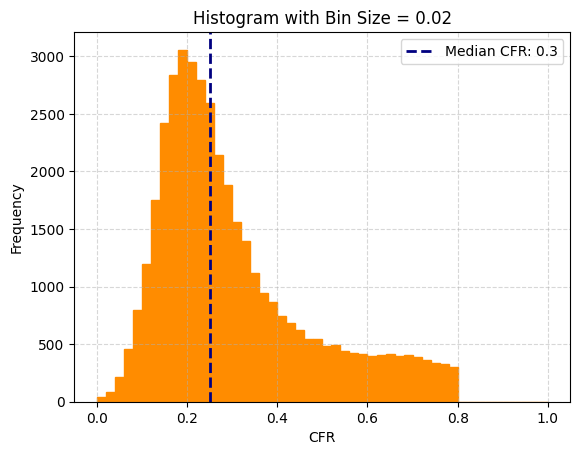

In [24]:
MFX_Data =  MFX_Data[MFX_Data['vld'] == True]

#%% plot cfr
MFX_CFR = MFX_Data['cfr'][MFX_Data['itr'] == 3]

# Compute cfr median
cfr_median = np.median(MFX_CFR )

plt.figure()
plt.hist(MFX_CFR, bins=np.arange(0, 1 + 0.02, 0.02 ), edgecolor='darkorange', color = 'darkorange')
plt.axvline(cfr_median, color='navy', linestyle='--', linewidth=2,
            label=f'Median CFR: {cfr_median:.1f}')
plt.legend()
plt.xlabel('CFR')
plt.ylabel('Frequency')
plt.title(f'Histogram with Bin Size = 0.02')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
# Iteration (ITR)
MFX_Data_fnl =  MFX_Data[MFX_Data['itr'] == max(MFX_Data['itr'])]

In [9]:
MFX_Data_vld_fnl =  MFX_Data[(MFX_Data['itr'] == max(MFX_Data['itr'])) & (MFX_Data['itr'] == max(MFX_Data['itr']))]

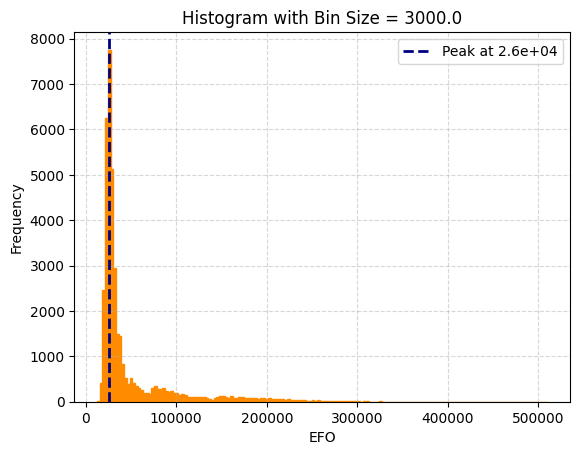

In [10]:
#%% Plot effective frequency at the Offset (EFO)
import matplotlib.pyplot as plt

MFX_EFO =  MFX_Data['efo'][MFX_Data['itr'] == np.max(MFX_Data['itr'])]

# Create bin edges  
bin_size = 3e3
bins = np.arange(np.min(MFX_EFO), np.max(MFX_EFO) + bin_size , bin_size )

# Compute histogram manually
counts, bin_edges = np.histogram(MFX_EFO, bins=bins)

# Compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Find the bin with the maximum count
peak_index = np.argmax(counts)
peak_value = bin_centers[peak_index]

# Plot histogram
plt.hist(MFX_EFO, bins=bins, edgecolor='darkorange', color = 'darkorange')
plt.axvline(peak_value, color='navy', linestyle='--', linewidth=2,
            label=f'Peak at {peak_value:.1e}')
plt.xlabel('EFO')
plt.ylabel('Frequency')
plt.title(f'Histogram with Bin Size = {bin_size}')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()



In [ ]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Output, VBox
from IPython.display import display

# Data and histogram
MFX_EFO = MFX_Data['efo'][MFX_Data['itr'] == np.max(MFX_Data['itr'])]
bin_size = 3e3
bins = np.arange(MFX_EFO.min(), MFX_EFO.max() + bin_size, bin_size)
counts, _ = np.histogram(MFX_EFO, bins=bins)
centers = (bins[:-1] + bins[1:]) / 2
peak = centers[counts.argmax()]

# Static figure (won't accumulate; we redraw inside a single Output)
fig, ax = plt.subplots()
ax.hist(MFX_EFO, bins=bins, edgecolor='darkorange', color='darkorange')
ax.axvline(peak, color='navy', ls='--', lw=2, label=f'Peak {peak:.1e}')
sel = ax.axvline(peak, color='crimson', lw=2, label='EFO threshold')
ax.set(xlabel='EFO', ylabel='Frequency', title=f'Histogram with Bin Size = {bin_size}')
ax.grid(True, ls='--', alpha=.5); ax.legend()
plt.close(fig)
fig_out, val_out = Output(), Output()
with fig_out: display(fig)

slider = FloatSlider(value=float(peak), min=float(bins[0]), max=float(bins[-1]),
                     step=float(bin_size), description='Select threshold:', readout_format='.2e',
                     continuous_update=False)
slider.layout.width = '400px'
slider.layout.height = '40px'

def on_change(c):
    x = float(c['new']); sel.set_xdata([x, x])
    with fig_out: fig_out.clear_output(wait=True); display(fig)
    with val_out: val_out.clear_output(wait=True); print(f'Selected EFO threshold: {x:.6g}')

slider.observe(on_change, 'value')
display(VBox([fig_out, slider, val_out]))

In [12]:
# Get the number of valid localizations and tids before efo filtering and after
efo_threshold = float(slider.value)
vld_localizations_vld = len(MFX_Data['itr'] == np.max(MFX_Data['itr']) )
num_of_tids_vld = len(np.unique(MFX_Data['tid']))

print(f'The number of TIDs is {num_of_tids_vld }')
print(f'The number of valid localizations is {vld_localizations_vld}')

MFX_Data_efo_filt =  MFX_Data[MFX_Data['efo'] < efo_threshold]

vld_localizations_efo_filt = len(MFX_Data_efo_filt['itr'] == np.max(MFX_Data_efo_filt['itr']) )
num_of_tids_efo_filt = len(np.unique(MFX_Data_efo_filt['tid']))

print(f'The number of TIDs after EFO filtering  is {num_of_tids_efo_filt}')
print(f'The number of valid localizations after EFO filtering is {vld_localizations_efo_filt }')

ex_tid = num_of_tids_vld  - num_of_tids_efo_filt
print(f'The number of excluded TIDs was {ex_tid}')
print(f'The number of excluded localizations was {vld_localizations_vld  - vld_localizations_efo_filt }')

The number of TIDs is 2091
The number of valid localizations is 85534
The number of TIDs after EFO filtering  is 2077
The number of valid localizations after EFO filtering is 66924
The number of excluded TIDs was 14
The number of excluded localizations was 18610


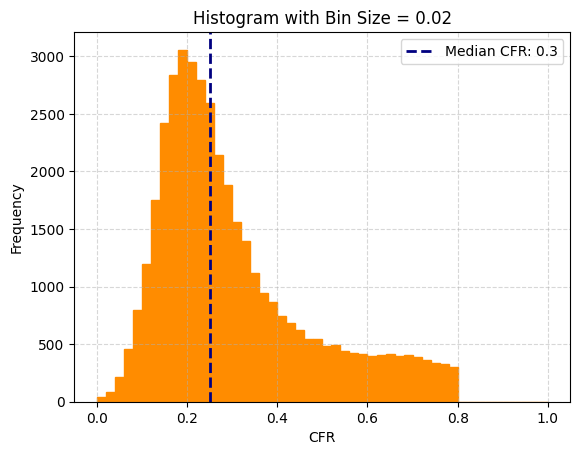

In [13]:
# Center frequency ratio (CFR)

MFX_Data =  MFX_Data[MFX_Data['vld'] == True]

#%% plot cfr
MFX_CFR = MFX_Data['cfr'][MFX_Data['itr'] == 3]

# Compute cfr median
cfr_median = np.median(MFX_CFR )

plt.figure()
plt.hist(MFX_CFR, bins=np.arange(0, 1 + 0.02, 0.02 ), edgecolor='darkorange', color = 'darkorange')
plt.axvline(cfr_median, color='navy', linestyle='--', linewidth=2,
            label=f'Median CFR: {cfr_median:.1f}')
plt.legend()
plt.xlabel('CFR')
plt.ylabel('Frequency')
plt.title(f'Histogram with Bin Size = 0.02')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
  # Get number of final localizations per trace 
unique_tids, inv_idx, locs_per_tid = np.unique(MFX_Data_vld_fnl['tid'],  return_inverse=True,return_counts=True) 

print(f'Minimum number of localizations per trace: {np.min(locs_per_tid)}')
# Keep only traces with at least 3 localizations
MFX_Data_vld_fnl_filt = MFX_Data_vld_fnl[locs_per_tid[inv_idx]>2] 

# Get number of final localizations per trace 
_,locs_per_tid_filt = np.unique(MFX_Data_vld_fnl_filt['tid'], return_counts=True) 
print(f'Minimum number of localizations per trace: {np.min(locs_per_tid_filt)}')

Minimum number of localizations per trace: 1
Minimum number of localizations per trace: 3


In [15]:
tid_ON_time = []
for tid in np.unique(MFX_Data_vld_fnl_filt['tid']):
    tid_ON_time.append(MFX_Data_vld_fnl_filt['tim'][MFX_Data_vld_fnl_filt['tid'] == tid][-1] - MFX_Data_vld_fnl_filt['tim'][MFX_Data_vld_fnl_filt['tid'] == tid][0])
tid_ON_time = np.vstack(tid_ON_time)    
print(f'The median trace ON time is {np.median(tid_ON_time): 0.2f} s')   

The median trace ON time is  0.24 s


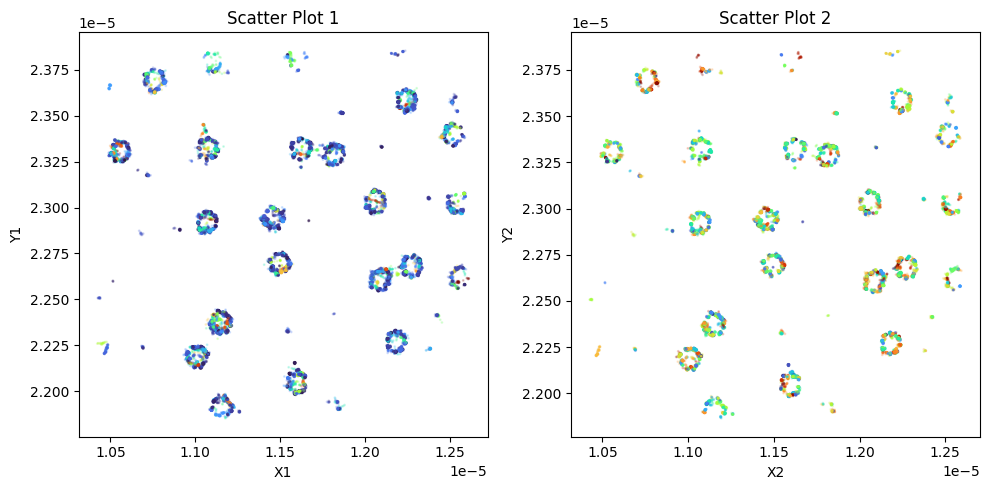

In [16]:
import matplotlib.pyplot as plt

end_to_end_dis = []
for tid in np.unique(MFX_Data_vld_fnl_filt['tid']):
     d_xyz = MFX_Data_vld_fnl_filt['loc'][MFX_Data_vld_fnl_filt['tid'] == tid,:][-1,:]- MFX_Data_vld_fnl_filt['loc'][MFX_Data_vld_fnl_filt['tid'] == tid,:][0,:]
     end_to_end_dis.append(np.sqrt(np.sum(d_xyz**2)) ) 
end_to_end_dis = np.vstack(end_to_end_dis)    


_, inv_indx = np.unique(MFX_Data_vld_fnl_filt['tid'], return_inverse = True)

# get localizations
locs = MFX_Data_vld_fnl_filt['loc']

#% Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# First subplot
axes[0].scatter(locs[:,0], locs[:,1], c = end_to_end_dis[inv_indx], cmap = 'turbo',alpha=0.2,s =1)
axes[0].set_title('Scatter Plot 1')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('Y1')

idx = end_to_end_dis[inv_indx]<20e-9
idx = idx.flatten()
# Second subplot
axes[1].scatter(locs[idx,0], locs[idx,1], c =end_to_end_dis[inv_indx][idx], cmap = 'turbo', alpha=0.2,s =1)
axes[1].set_title('Scatter Plot 2')
axes[1].set_xlabel('X2')
axes[1].set_ylabel('Y2')

# Layout adjustment
plt.tight_layout()
plt.show()


In [17]:
import numpy as np

# Read MINFLUX Data exported as .NPY
MFX_Data = np.load(glob.glob(os.path.join(data_path, "*.npy"))[0])

# Keep only valid final localizations
MFX_Data  = MFX_Data[(MFX_Data['vld'] == True) & (MFX_Data['itr'] == np.max(MFX_Data['itr']))]

# Get number of final localizations per trace 
unique_tids, inv_idx, locs_per_tid = np.unique(MFX_Data['tid'],  return_inverse=True,return_counts=True) 

# Exclude traces with less than 3 localizations
MFX_Data = MFX_Data[locs_per_tid[inv_idx]>2]

# Compute trace standard deviation
grouped_std = []
for tid in np.unique(MFX_Data['tid']):
    grouped_std.append(np.array([MFX_Data['loc'][MFX_Data['tid'] == tid, :].std(ddof=1, axis = 0)]))

grouped_std = np.vstack(grouped_std)
# Get median value of trace standard deviation
meas_loc_precision = np.median(grouped_std, axis = 0)
print(f'Localization precision in x is: {meas_loc_precision[0]: .1e}\nLocalization precision in y is: {meas_loc_precision[1]: .1e}\nLocalization precision in z is: {meas_loc_precision[2]: .1e}')


Localization precision in x is:  3.2e-09
Localization precision in y is:  2.5e-09
Localization precision in z is:  2.1e-28


In [18]:
# Read MINFLUX Data exported as .NPY
MFX_Nup3D = np.load(glob.glob(os.path.join(data_path, "*.npy"))[0]) 

# Keep only valid final localizations
MFX_Nup3D  = MFX_Nup3D[(MFX_Nup3D['vld'] == True) & (MFX_Nup3D['itr'] == np.max(MFX_Nup3D['itr']))]

# Get number of final localizations per trace 
unique_tids, inv_idx, locs_per_tid = np.unique(MFX_Nup3D['tid'],  return_inverse=True,return_counts=True) 

# Exclude traces with less than 3 localizations
MFX_Nup3D = MFX_Nup3D[locs_per_tid[inv_idx]>2]

# Compute trace standard deviation
grouped_std = []
for tid in np.unique(MFX_Nup3D['tid']):
    grouped_std.append(np.array([MFX_Nup3D['loc'][MFX_Nup3D['tid'] == tid, :].std(ddof=1, axis = 0)]))

grouped_std = np.vstack(grouped_std)
# Get median value of trace standard deviation
meas_loc_precision = np.median(grouped_std, axis = 0)
print(f'Localization precision in x is: {meas_loc_precision[0]: .1e}\nLocalization precision in y is: {meas_loc_precision[1]: .1e}\nLocalization precision in z is: {meas_loc_precision[2]: .1e}')


Localization precision in x is:  3.2e-09
Localization precision in y is:  2.5e-09
Localization precision in z is:  2.1e-28
